### Teoría y Componentes: FALQON para el Problema de Partición de Números

Este bloque de código implementa una simulación del algoritmo FALQON para resolver una instancia específica del **problema de partición de números**. El objetivo es encontrar la división de un conjunto de números en dos subconjuntos cuyas sumas sean lo más iguales posible. Este problema se formula como un **QUBO (Quadratic Unconstrained Binary Optimization)**.

#### 1. Construcción del Hamiltoniano del Problema ($H_p$)

La función de coste QUBO se traduce a un Hamiltoniano usando los operadores $\hat{\tilde{Z}}_k = \frac{1}{2}(\mathbb{I} - \hat{\sigma}_z^k)$. Para nuestro problema de partición, el Hamiltoniano tiene la forma general:

$$
\Large
H_p = \sum_{i,j=1}^{n} Q_{ij} \hat{\tilde{Z}}_i \otimes \hat{\tilde{Z}}_j + \sum_{i=1}^{n} B_i \hat{\tilde{Z}}_i
$$

Esta construcción es realizada por la función `get_problem_hamiltonian(Z_ops_mapped, n, Q, B)`. La matriz $Q$ se deriva de la matriz `A` del problema, y `Z_ops_mapped` contiene la lista de los operadores $\hat{\tilde{Z}}_k$.

#### 2. Construcción del Hamiltoniano Impulsor ($H_d$)

Para permitir que el sistema explore diferentes configuraciones, se introduce un Hamiltoniano impulsor. Este se construye como una suma de operadores Pauli-X:

$$
\Large
H_d = \sum_{k=1}^{n} \hat{X}_k
$$

Esta tarea es realizada por la función `get_drift_hamiltonian(X_ops, n)`.

#### 3. El Protocolo de Simulación (`qubo_protocol`)

El núcleo de la simulación es la evolución temporal iterativa. En cada paso de tiempo `dt`, se siguen los principios de FALQON:

1.  **Se calcula la señal de feedback $A(t)$:** Se evalúa matemáticamente el valor esperado a partir del estado actual $|\psi\rangle$ sin destruirlo.
    $$
    \Large
    A(t) = -2 \, \text{Im} \left( \langle\psi(t)| H_d H_p |\psi(t)\rangle \right)
    $$
2.  **Se determina el control $\beta(t)$:** Se usa una ley de control lineal simple con una ganancia `w`.
    $$
    \Large
    \beta(t) = -w \cdot A(t)
    $$
3.  **Se evoluciona el estado $|\psi\rangle$:** El estado avanza en el tiempo bajo la influencia del Hamiltoniano total $H(t) = H_p + \beta(t) H_d$. Este paso se realiza eficientemente en la GPU mediante la exponencial de la matriz.
    $$
    \Large
    |\psi(t+dt)\rangle = e^{-i(H_p + \beta(t) H_d)dt} |\psi(t)\rangle
    $$

La función `main` orquesta todo el proceso: inicializa los parámetros, llama a las funciones de construcción, ejecuta el `qubo_protocol`, y finalmente analiza y grafica los resultados.

In [9]:
import time
import cupy as np  # 'np' se refiere a cupy para las operaciones en la GPU
import numpy as numpy_cpu # Usaremos 'numpy_cpu' para las operaciones en CPU
import cupyx.scipy.linalg as linalg # Exponencial de matriz en GPU
import scipy.linalg as cpu_linalg   # Usaremos scipy solo para diagonalización en CPU
import matplotlib.pyplot as plt

--- INICIANDO SIMULACIÓN FALQON PARA NUMBER PARTITIONING (GPU) ---
Configurando para n = 8 qubits...
1. Construyendo operadores y Hamiltonianos en la GPU...
2. Calculando la energía mínima exacta...
   >>> La energía mínima teórica es: -6889.00

3. Iniciando el bucle de simulación principal con 10000 pasos en la GPU (dt=0.1)...
4. Moviendo estado final de GPU a CPU para visualización...
   >>> Mínimo obtenido por simulación: -6769.16
   >>> Error porcentual: 1.74%

5. Generando las gráficas...


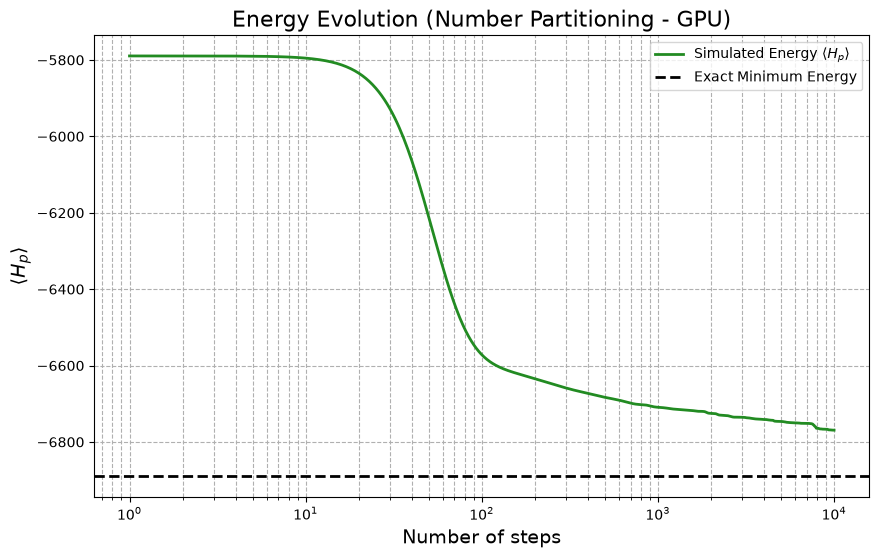

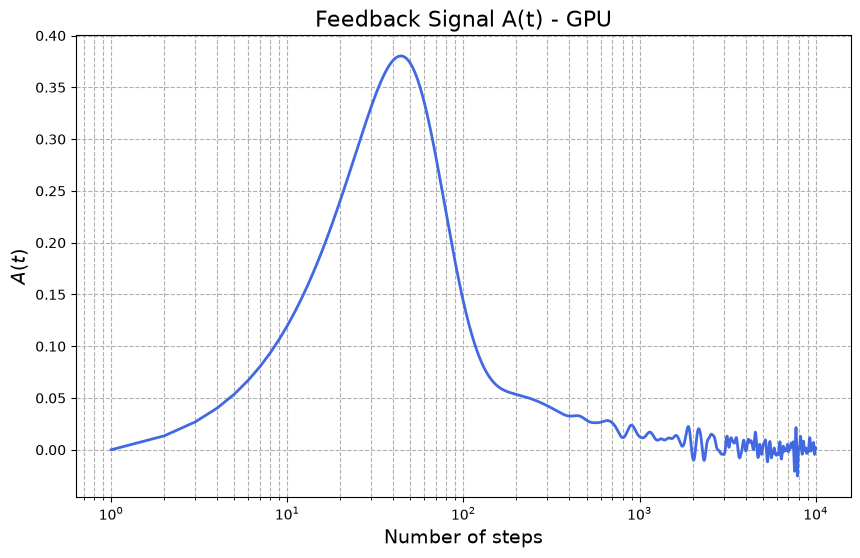

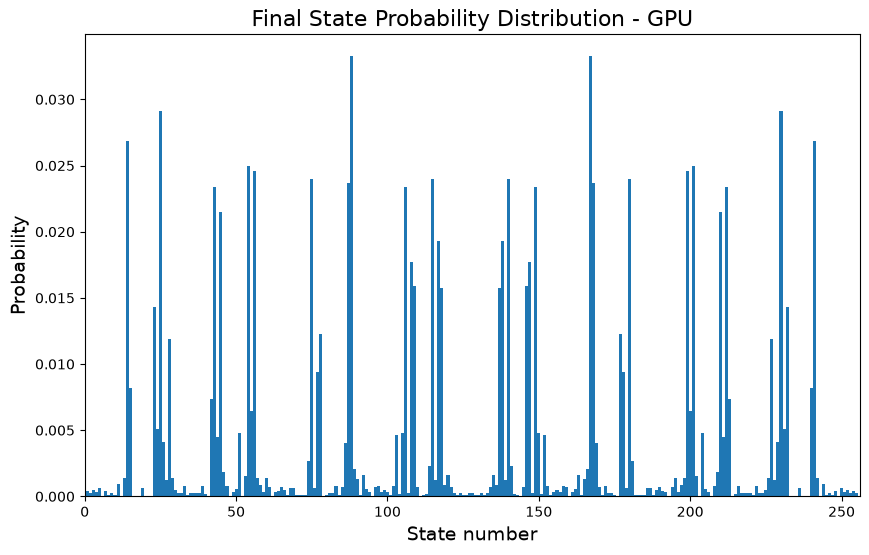

In [3]:
# =============================================================================
# SCRIPT FINAL: SIMULACIÓN DE PARTICIÓN DE NÚMEROS EN GPU (CUDA)
# =============================================================================

def get_operator(op, i, n_spins):
    """Crea la matriz de un operador que actúa sobre el qubit 'i'."""
    op_list = [np.identity(2, dtype=complex) for _ in range(n_spins)]
    op_list[i] = op
    full_op = op_list[0]
    for k in range(1, n_spins):
        full_op = np.kron(full_op, op_list[k])
    return full_op

def get_problem_hamiltonian(Z_ops_mapped, n, Q, B):
    """Construye el Hamiltoniano H_p para un QUBO genérico."""
    H_local = np.zeros((2**n, 2**n), dtype=complex)
    H_bilocal = np.zeros((2**n, 2**n), dtype=complex)
    for i in range(n):
        H_local += B[i] * Z_ops_mapped[i]
        for j in range(n):
            H_bilocal += Q[i, j] * (Z_ops_mapped[i] @ Z_ops_mapped[j])
    return H_local + H_bilocal

def get_drift_hamiltonian(X_ops, n):
    """Construye el Hamiltoniano impulsor Hd."""
    Hd = np.zeros((2**n, 2**n), dtype=complex)
    for op in X_ops:
        Hd += op
    return Hd

def f_control(x):
    """Función de ley de control (lineal)."""
    return x

def qubo_protocol(psi_initial, H0, Hd, dt, steps, w):
    """Bucle principal de la simulación FALQON en la GPU."""
    psi = psi_initial.copy()
    avg_E0_cpu = numpy_cpu.zeros(steps, dtype=numpy_cpu.float64)
    At_cpu = numpy_cpu.zeros(steps, dtype=numpy_cpu.float64)
    Hd_H0 = Hd @ H0

    for s in range(steps):
        At_s = -2 * np.imag(psi.conj().T @ Hd_H0 @ psi)
        beta = -w * f_control(At_s)
        H = H0 + beta * Hd
        U = linalg.expm(-1j * H * dt) # Exponencial de matriz en GPU
        psi = U @ psi
        energy_s = np.real(psi.conj().T @ H0 @ psi)
        
        # Extrae el valor escalar y lo guarda en un array de CPU
        At_cpu[s] = At_s.item()
        avg_E0_cpu[s] = energy_s.item()
        
    return avg_E0_cpu, psi, At_cpu

# 3. FUNCIÓN PRINCIPAL DE EJECUCIÓN
# -----------------------------------------------------------------------------
def main():
    """Función principal que configura y ejecuta toda la simulación."""
    print("--- INICIANDO SIMULACIÓN FALQON PARA NUMBER PARTITIONING (GPU) ---")
    start_time_total = time.time()
    
    n = 8
    print(f"Configurando para n = {n} qubits...")
    
    # Matrices del problema de Partición de Números
    B_cpu = numpy_cpu.zeros(n)
    A_cpu = numpy_cpu.array([
        [-3525, 175, 325, 775, 1050, 425, 525, 250],
        [175, -1113, 91, 217, 294, 119, 147, 70],
        [325, 91, -1989, 403, 546, 221, 273, 130],
        [775, 217, 403, -4185, 1302, 527, 651, 310],
        [1050, 294, 546, 1302, -5208, 714, 882, 420],
        [425, 119, 221, 527, 714, -2533, 357, 170],
        [525, 147, 273, 651, 882, 357, -3045, 210],
        [250, 70, 130, 310, 420, 170, 210, -1560]
    ])
    
    # Mover matrices a la GPU
    A = np.asarray(A_cpu)
    B = np.asarray(B_cpu)

    Anorm = numpy_cpu.linalg.norm(A_cpu, ord=1)
    Q = A / Anorm
    
    print("1. Construyendo operadores y Hamiltonianos en la GPU...")
    pauli_x = np.asarray(numpy_cpu.array([[0, 1], [1, 0]], dtype=complex))
    pauli_z = np.asarray(numpy_cpu.array([[1, 0], [0, -1]], dtype=complex))
    identity = np.identity(2**n, dtype=complex)
    
    X_ops = [get_operator(pauli_x, k, n) for k in range(n)]
    Z_ops_pauli = [get_operator(pauli_z, k, n) for k in range(n)]
    
    Z_ops_mapped = [(identity - Z) / 2 for Z in Z_ops_pauli]
    
    H0 = get_problem_hamiltonian(Z_ops_mapped, n, Q, B)
    Hd = get_drift_hamiltonian(X_ops, n)
    
    print("2. Calculando la energía mínima exacta...")
    eigenvalues_cpu, _ = cpu_linalg.eigh(np.asnumpy(H0))
    Emin_normalized = numpy_cpu.min(eigenvalues_cpu)
    Emin = Anorm * Emin_normalized
    print(f"   >>> La energía mínima teórica es: {Emin:.2f}\n")

    psi_initial = np.ones((2**n, 1), dtype=complex)
    psi_initial /= np.linalg.norm(psi_initial)
    
    # Parámetros ajustados para estabilidad
    dt = 0.1
    steps = 10000
    w = 0.1
    
    print(f"3. Iniciando el bucle de simulación principal con {steps} pasos en la GPU (dt={dt})...")
    avg_E0, psi_final_gpu, At = qubo_protocol(psi_initial, H0, Hd, dt, steps, w)
    
    print("4. Moviendo estado final de GPU a CPU para visualización...")
    psi_final = np.asnumpy(psi_final_gpu)
    
    min_obtenido = Anorm * avg_E0[-1]
    error_porcentual = 100 * abs(min_obtenido - Emin) / abs(Emin)
    print(f"   >>> Mínimo obtenido por simulación: {min_obtenido:.2f}")
    print(f"   >>> Error porcentual: {error_porcentual:.2f}%\n")
    
    print("5. Generando las gráficas...")
    steps_range = numpy_cpu.arange(1, steps + 1)


    # Crear el eje X para las gráficas
    steps_range = numpy_cpu.arange(1, steps + 1)
    
    # --- Gráfica 1: Evolución de la Energía ---
    plt.figure(figsize=(10, 6))
    plt.plot(steps_range, Anorm * avg_E0, '-', color='forestgreen', linewidth=2, label='Simulated Energy $\\langle H_p \\rangle$')
    plt.axhline(y=Emin, linestyle='--', color='black', linewidth=2, label='Exact Minimum Energy')
    plt.xlabel('Number of steps', fontsize=14)
    plt.ylabel('$\\langle H_p \\rangle$', fontsize=14)
    plt.xscale('log')
    plt.title('Energy Evolution (Number Partitioning - GPU)', fontsize=16)
    plt.grid(True, which="both", ls="--")
    plt.legend()
    plt.savefig("gpu_partitioning_energia.png") # Guarda la figura en un archivo
    plt.show()
    
    # --- Gráfica 2: Señal de Feedback ---
    plt.figure(figsize=(10, 6))
    plt.plot(steps_range, At, '-', color='royalblue', linewidth=2)
    plt.xlabel('Number of steps', fontsize=14)
    plt.ylabel('$A(t)$', fontsize=14)
    plt.xscale('log')
    plt.title('Feedback Signal A(t) - GPU', fontsize=16)
    plt.grid(True, which="both", ls="--")
    plt.savefig("gpu_partitioning_feedback.png") # Guarda la figura
    plt.show()
    
    # --- Gráfica 3: Distribución de Probabilidad Final ---
    plt.figure(figsize=(10, 6))
    # Calcular las probabilidades a partir del estado final (que está en la CPU)
    probabilities = numpy_cpu.abs(psi_final)**2
    plt.bar(range(2**n), probabilities.flatten(), width=1.0)
    plt.xlabel('State number', fontsize=14)
    plt.ylabel('Probability', fontsize=14)
    plt.title('Final State Probability Distribution - GPU', fontsize=16)
    plt.xlim([0, 2**n])
    plt.savefig("gpu_partitioning_probabilidades.png") # Guarda la figura
    plt.show()
      
# PUNTO DE ENTRADA DEL SCRIPT
if __name__ == "__main__":
    main()

### Teoría y Componentes: FALQON para el Problema de Max-Cut

Este bloque de código adapta la simulación del algoritmo FALQON para resolver el **problema de Max-Cut**. El objetivo es dividir los nodos de un grafo en dos conjuntos de manera que se maximice el número de aristas que conectan ambos conjuntos. Aunque el objetivo es maximizar, el algoritmo FALQON es un minimizador. Por lo tanto, el problema se reformula para **minimizar el negativo** de la función objetivo de MaxCut.

#### 1. Construcción del Hamiltoniano del Problema ($H_p$)

El Hamiltoniano para MaxCut se basa en el modelo de Ising y tiene una forma muy específica que depende de la estructura del grafo. Por cada arista $(i,j)$ del grafo, se añade un término al Hamiltoniano. Como queremos minimizar $-(\text{cortes})$, el Hamiltoniano toma la forma:

$$
\Large
H_p = - \sum_{(i,j) \in \text{Edges}} \frac{1}{2}(\mathbb{I} - \hat{\sigma}_z^i \otimes \hat{\sigma}_z^j)
$$

Este Hamiltoniano es construido por la nueva función `create_maxcut_hamiltonian(n, edges, pauli_z_ops)`. En lugar de una matriz `Q` densa, esta función solo necesita la lista de `edges` (aristas) del grafo. Los operadores utilizados son los Pauli-Z estándar ($\hat{\sigma}_z$), no los mapeados.

#### 2. Construcción del Hamiltoniano Impulsor ($H_d$)

El rol y la construcción del Hamiltoniano impulsor son **idénticos** al caso anterior. Sigue siendo el motor que permite la exploración del espacio de estados.

$$
\Large
H_d = \sum_{k=1}^{n} \hat{X}_k
$$

Esta tarea sigue siendo realizada por la misma función `get_drift_hamiltonian(X_ops, n)`.

#### 3. El Protocolo de Simulación (`qubo_protocol`)

La belleza de este enfoque es que el motor de la simulación, la función `qubo_protocol`, **no necesita ningún cambio**. Es completamente agnóstica al problema. Acepta cualquier par de matrices $H_p$ y $H_d$ y aplica el mismo bucle iterativo de FALQON para encontrar el estado de mínima energía de $H_p$.

El flujo dentro del bucle sigue siendo:
1.  Calcular $A(t) = -2 \, \text{Im} \left( \langle\psi(t)| H_d H_p |\psi(t)\rangle \right)$
2.  Calcular $\beta(t) = -w \cdot A(t)$
3.  Evolucionar $|\psi(t+dt)\rangle = e^{-i(H_p + \beta(t) H_d)dt} |\psi(t)\rangle$

La función `main` en este caso define una estructura de grafo (`edges`), llama a `create_maxcut_hamiltonian` para construir el $H_p$ específico de MaxCut, y luego procede con la simulación y el análisis de resultados de la misma manera.

--- INICIANDO SIMULACIÓN FALQON PARA MAXCUT (GPU) ---
Configurando para n = 8 qubits...
1. Construyendo operadores y Hamiltonianos en la GPU...
   ... Hecho en 0.20 segundos.
2. Calculando la energía mínima exacta...
   ... Hecho en 0.03 segundos.
   >>> La energía mínima teórica es: -8.00

3. Iniciando el bucle de simulación principal con 10000 pasos en la GPU (dt=0.1)...
   ... ¡Simulación completada en 152.79 segundos!

4. Moviendo estado final de GPU a CPU para visualización...
   >>> Mínimo obtenido por simulación: -6.26
   >>> Error porcentual: 21.69%

5. Generando las gráficas...


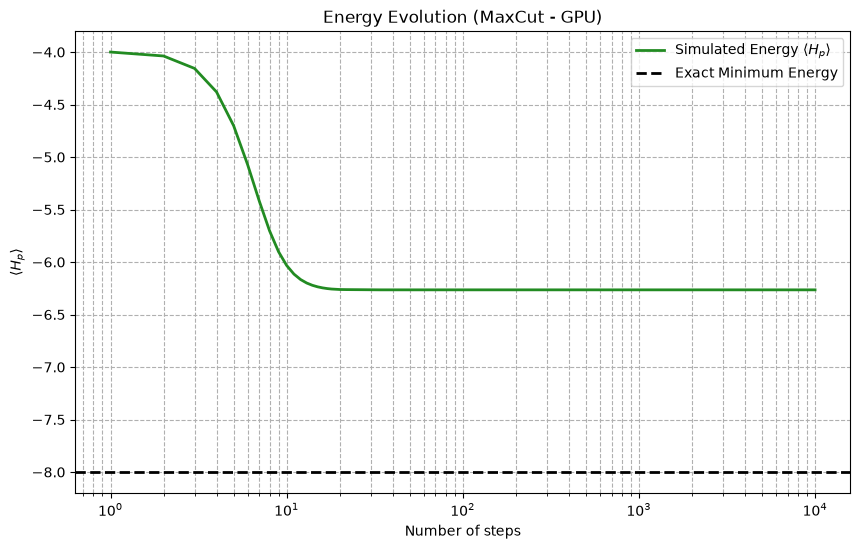

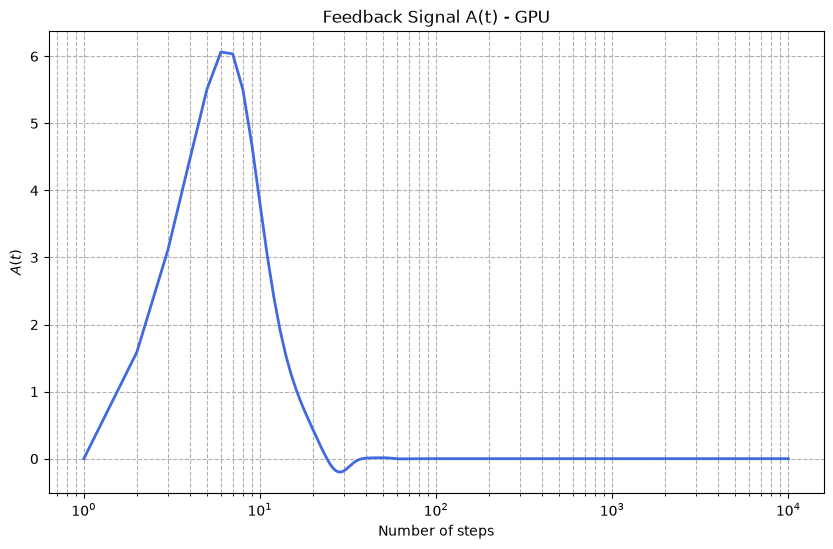

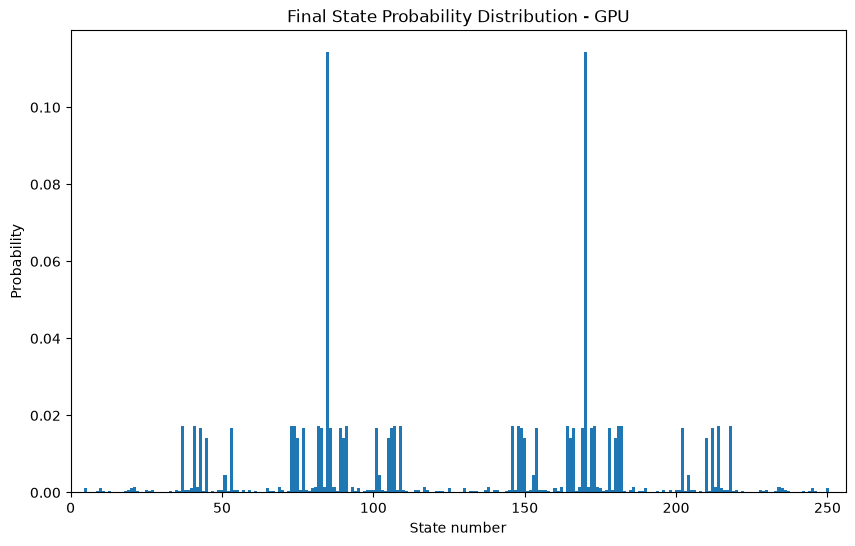


--- SIMULACIÓN FINALIZADA ---
Tiempo de ejecución total: 154.64 segundos.


In [13]:
# =============================================================================
# SCRIPT COMPLETO: SIMULACIÓN DE MAXCUT CON FALQON ACELERADA POR GPU
# =============================================================================

def get_operator(op, i, n_spins):
    """
    Crea la matriz de un operador que actúa sobre el qubit 'i' en un sistema de n_spins.
    """
    op_list = [np.identity(2, dtype=complex) for _ in range(n_spins)]
    op_list[i] = op
    
    full_op = op_list[0]
    for k in range(1, n_spins):
        full_op = np.kron(full_op, op_list[k])
    return full_op

def create_maxcut_hamiltonian(n, edges, pauli_z_ops):
    """
    Crea el Hamiltoniano H_p para un problema de MaxCut.
    El signo negativo es crucial porque FALQON minimiza, y MaxCut es un problema de maximización.
    """
    identity = np.identity(2**n, dtype=complex)
    H_p = np.zeros((2**n, 2**n), dtype=complex)
    
    for i, j in edges:
        Z_i = pauli_z_ops[i]
        Z_j = pauli_z_ops[j]
        H_p += 0.5 * (identity - (Z_i @ Z_j))
        
    return -H_p

def get_drift_hamiltonian(X_ops, n):
    """
    Construye el Hamiltoniano impulsor Hd.
    """
    Hd = np.zeros((2**n, 2**n), dtype=complex)
    for op in X_ops:
        Hd += op
    return Hd

def f_control(x):
    """Función de ley de control (lineal)."""
    return x

def qubo_protocol(psi_initial, H0, Hd, dt, steps, w):
    """
    Bucle principal de la simulación FALQON en la GPU.
    """
    psi = psi_initial.copy()
    avg_E0 = numpy_cpu.zeros(steps, dtype=numpy_cpu.float64)
    At = numpy_cpu.zeros(steps, dtype=numpy_cpu.float64)
    Hd_H0 = Hd @ H0

    for s in range(steps):
        At_s = -2 * np.imag(psi.conj().T @ Hd_H0 @ psi)
        beta = -w * f_control(At_s)
        H = H0 + beta * Hd
        U = linalg.expm(-1j * H * dt)
        psi = U @ psi
        energy_s = np.real(psi.conj().T @ H0 @ psi)
        
        At[s] = At_s.item()
        avg_E0[s] = energy_s.item()
        
    return avg_E0, psi, At

# 3. FUNCIÓN PRINCIPAL DE EJECUCIÓN
# -----------------------------------------------------------------------------
def main():
    """
    Función principal que configura y ejecuta toda la simulación para MaxCut.
    """
    print("--- INICIANDO SIMULACIÓN FALQON PARA MAXCUT (GPU) ---")
    start_time_total = time.time()
    
    n = 8
    print(f"Configurando para n = {n} qubits...")
    edges = [(i, (i + 1) % n) for i in range(n)] # Grafo de anillo

    print("1. Construyendo operadores y Hamiltonianos en la GPU...")
    start_time_setup = time.time()
    pauli_x = np.asarray(numpy_cpu.array([[0, 1], [1, 0]], dtype=complex))
    pauli_z = np.asarray(numpy_cpu.array([[1, 0], [0, -1]], dtype=complex))
    X_ops = [get_operator(pauli_x, k, n) for k in range(n)]
    Z_ops_pauli = [get_operator(pauli_z, k, n) for k in range(n)]
    H0 = create_maxcut_hamiltonian(n, edges, Z_ops_pauli)
    Hd = get_drift_hamiltonian(X_ops, n)
    end_time_setup = time.time()
    print(f"   ... Hecho en {end_time_setup - start_time_setup:.2f} segundos.")
    
    print("2. Calculando la energía mínima exacta...")
    start_time_diag = time.time()
    eigenvalues_cpu, _ = cpu_linalg.eigh(np.asnumpy(H0))
    Emin = numpy_cpu.min(eigenvalues_cpu)
    end_time_diag = time.time()
    print(f"   ... Hecho en {end_time_diag - start_time_diag:.2f} segundos.")
    print(f"   >>> La energía mínima teórica es: {Emin:.2f}\n")

    psi_initial = np.ones((2**n, 1), dtype=complex)
    psi_initial /= np.linalg.norm(psi_initial)
    
    dt = 0.1
    steps = 10000
    w = 0.1
    
    print(f"3. Iniciando el bucle de simulación principal con {steps} pasos en la GPU (dt={dt})...")
    start_time_sim = time.time()
    avg_E0, psi_final_gpu, At = qubo_protocol(psi_initial, H0, Hd, dt, steps, w)
    end_time_sim = time.time()
    print(f"   ... ¡Simulación completada en {end_time_sim - start_time_sim:.2f} segundos!\n")
    
    print("4. Moviendo estado final de GPU a CPU para visualización...")
    psi_final = np.asnumpy(psi_final_gpu)
    
    min_obtenido = avg_E0[-1]
    error_porcentual = 100 * abs(min_obtenido - Emin) / abs(Emin) if abs(Emin) > 1e-9 else 0
    print(f"   >>> Mínimo obtenido por simulación: {min_obtenido:.2f}")
    print(f"   >>> Error porcentual: {error_porcentual:.2f}%\n")
    
    print("5. Generando las gráficas...")
    steps_range = numpy_cpu.arange(1, steps + 1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(steps_range, avg_E0, '-', color='forestgreen', linewidth=2, label='Simulated Energy $\\langle H_p \\rangle$')
    plt.axhline(y=Emin, linestyle='--', color='black', linewidth=2, label='Exact Minimum Energy')
    plt.xlabel('Number of steps'); plt.ylabel('$\\langle H_p \\rangle$'); plt.xscale('log')
    plt.title('Energy Evolution (MaxCut - GPU)'); plt.grid(True, which="both", ls="--")
    plt.legend(); plt.savefig("gpu_maxcut_energia.png")
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(steps_range, At, '-', color='royalblue', linewidth=2)
    plt.xlabel('Number of steps'); plt.ylabel('$A(t)$'); plt.xscale('log')
    plt.title('Feedback Signal A(t) - GPU'); plt.grid(True, which="both", ls="--")
    plt.savefig("gpu_maxcut_feedback.png")
    plt.show()
    
    plt.figure(figsize=(10, 6))
    probabilities = numpy_cpu.abs(psi_final)**2
    plt.bar(range(2**n), probabilities.flatten(), width=1.0)
    plt.xlabel('State number'); plt.ylabel('Probability')
    plt.title('Final State Probability Distribution - GPU'); plt.xlim([0, 2**n])
    plt.savefig("gpu_maxcut_probabilidades.png")
    plt.show()
    
    end_time_total = time.time()
    print(f"\n--- SIMULACIÓN FINALIZADA ---")
    print(f"Tiempo de ejecución total: {end_time_total - start_time_total:.2f} segundos.")

# 4. PUNTO DE ENTRADA DEL SCRIPT
# -----------------------------------------------------------------------------
if __name__ == "__main__":
    main()